In [17]:
#1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [18]:
#2. Load Dataset
df = pd.read_csv("IMDB_Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [19]:
#3. Preprocessing
# Convert labels to numeric
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

# Remove HTML tags
df['review'] = df['review'].str.replace('<br />', '', regex=False)

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. The filming tec...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [20]:
#4. Train-Test Split
X = df['review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
#5. Convert Text → Numbers (TF-IDF)
vectorizer = TfidfVectorizer(max_features=10000)

X_train = vectorizer.fit_transform(X_train).toarray()
X_test = vectorizer.transform(X_test).toarray()

In [22]:
#6. Build Deep Neural Network
model = Sequential([
    Dense(16, activation='relu', input_shape=(10000,)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

c:\Users\vishw\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
#7. Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [24]:
#8. Train Model
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=512,
    validation_split=0.2
)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.7872 - loss: 0.6330 - val_accuracy: 0.8634 - val_loss: 0.5282
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8877 - loss: 0.4027 - val_accuracy: 0.8859 - val_loss: 0.3230
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9123 - loss: 0.2547 - val_accuracy: 0.8935 - val_loss: 0.2641
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9300 - loss: 0.1982 - val_accuracy: 0.8955 - val_loss: 0.2536
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9412 - loss: 0.1677 - val_accuracy: 0.8957 - val_loss: 0.2541


In [25]:
#9. Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8964 - loss: 0.2481
Test Accuracy: 0.896399974822998


In [26]:
#10. Predictions
predictions = model.predict(X_test)

for i in range(5):
    print("Predicted:", predictions[i][0], "Actual:", y_test.iloc[i])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Predicted: 0.35137972 Actual: 1
Predicted: 0.929823 Actual: 1
Predicted: 0.010508743 Actual: 0
Predicted: 0.98519194 Actual: 1
Predicted: 0.049179267 Actual: 0


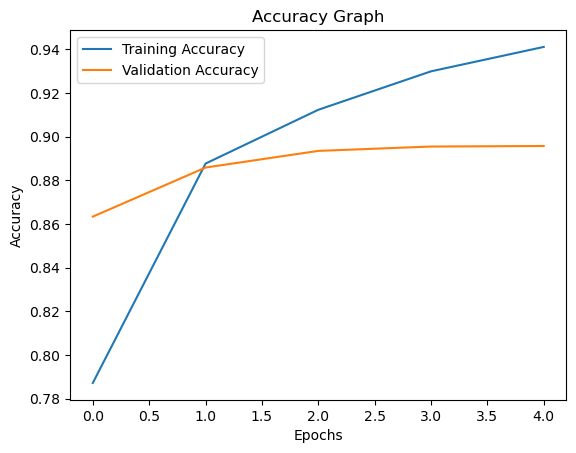

In [27]:
#11. Accuracy Graph
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.legend()
plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()